# Discrete gesture decoder evaluation

In [5]:
import os
import torch
from pytorch_lightning import Trainer
from hydra import initialize, compose
from hydra.utils import instantiate
from omegaconf import OmegaConf
from matplotlib import pyplot as plt
import seaborn as sns

from generic_neuromotor_interface.cler import GestureType, compute_cler
from generic_neuromotor_interface.data import make_dataset

TASK_NAME = "discrete_gestures"
EMG_DATA_DIR = "/Volumes/Crucial X9/emg_data"
MODELS_DIR = "/Volumes/Crucial X9/emg_models"

## Download Data Subset and Model Files

Before running this notebook, make sure you have downloaded the data (small subset) and model checkpoint.

You can do so with the following cell:

In [2]:
# Equivalent to README instructions.

from generic_neuromotor_interface.scripts.download_data import download_data
from generic_neuromotor_interface.scripts.download_models import download_models

download_data(TASK_NAME, "small_subset", EMG_DATA_DIR)
download_models(TASK_NAME, MODELS_DIR)

KeyboardInterrupt: 

In [6]:
if not os.path.exists(os.path.expanduser(EMG_DATA_DIR)):
    raise FileNotFoundError(f"The EMG data path does not exist: {EMG_DATA_DIR}")

if not os.path.exists(os.path.expanduser(MODELS_DIR)):
    raise FileNotFoundError(f"The models path does not exist: {MODELS_DIR}")

## Load model config

In [7]:
"""Load model config"""

config_path = os.path.join(os.path.expanduser(MODELS_DIR), TASK_NAME, "model_config.yaml")
config = OmegaConf.load(config_path)

## Load model checkpoint

In [8]:
"""Load model checkpoint"""

model_ckpt_path = os.path.join(
    os.path.expanduser(MODELS_DIR),
    TASK_NAME,
    "model_checkpoint.ckpt"
)
model = instantiate(config.lightning_module)
model = model.load_from_checkpoint(
    model_ckpt_path,
    map_location=torch.device("cpu"),
)

/opt/homebrew/Caskroom/miniconda/base/envs/neuromotor/lib/python3.12/site-packages/pytorch_lightning/utilities/parsing.py:262: UserWarning: Attribute 'network' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['network'])`.
  rank_zero_warn(
/opt/homebrew/Caskroom/miniconda/base/envs/neuromotor/lib/python3.12/site-packages/lightning_lite/utilities/cloud_io.py:48: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be al

## Instantiate data module

In [9]:
"""Assemble the data module"""

# Update DataModule config with data path
config["data_module"]["data_location"] = os.path.expanduser(EMG_DATA_DIR)
if "from_csv" in config["data_module"]["data_split"]["_target_"]:
    config["data_module"]["data_split"]["csv_filename"] = os.path.join(
        os.path.expanduser(EMG_DATA_DIR),
        f"{TASK_NAME}_corpus.csv"
    )

datamodule = instantiate(config["data_module"])

## Run inference on one test dataset

In [10]:
"""Grab one test dataset"""

test_dataset = make_dataset(
    datamodule.data_location,
    partition_dict={"discrete_gestures_user_002_dataset_000": None},  # from discrete_gestures_mini_split.yaml
    transform=datamodule.transform,
    emg_augmentation=None,
    window_length=None,
    stride=None,
    jitter=False,
)

sample = test_dataset[0]

[setup] Loading datasets for split None: 100%|██████████| 1/1 [00:00<00:00,  1.27it/s]


In [11]:
"""Run inference"""

model.eval()

# unpack sample
emg = sample["emg"]
emg_times = sample["timestamps"]
labels = sample["prompts"]

# compute model outputs
with torch.no_grad():
    logits = model(emg.unsqueeze(0))

logits = logits[0]
    
# convert logits to probabilities
probs = torch.nn.Sigmoid()(logits)

# get timestamps associated with each predicted probability
prob_times = emg_times[model.network.left_context::model.network.stride]

In [12]:
"""Evaluate CLER"""

cler = compute_cler(probs, prob_times, labels)

print("CLER on this dataset:", cler)

CLER on this dataset: 0.13421496168030211


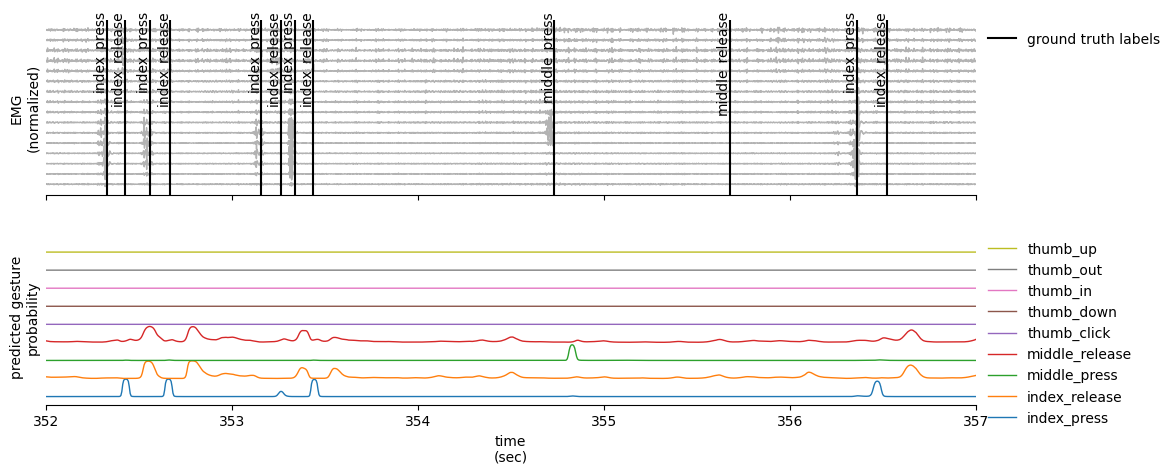

In [13]:
"""Plot predictions and targets"""

fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True, sharey=False)

t0 = emg_times[0]

# plot EMG
ax = axes[0]
spacing = 200
for channel_index, channel_data in enumerate(emg):
    ax.plot(
        emg_times - t0,
        channel_data + channel_index * spacing,
        linewidth=1,
        color="0.7",
    )

ax.set_ylim([-spacing, len(emg) * spacing])
ax.set_yticks([])

sns.despine(ax=ax, left=True)
    
# labels
ax = axes[1]
for gesture in GestureType:
    prob_index = gesture.value
    ax.plot(
        prob_times - t0,
        probs[prob_index] + prob_index,
        linewidth=1,
        label=gesture.name
    )

ax.set_yticks([])

sns.despine(ax=ax, left=True)

legends, handles = ax.get_legend_handles_labels()
ax.legend(
    legends[::-1],
    handles[::-1],
    loc="upper left",
    ncols=1,
    bbox_to_anchor=(1.0, 1.0),
    frameon=False
)

ax.set_xlim([352, 357])

axes[0].set_ylabel("EMG\n(normalized)")
axes[1].set_ylabel("predicted gesture\nprobability")
axes[1].set_xlabel("time\n(sec)")


tmin, tmax = ax.get_xlim()
_, ymax = axes[0].get_ylim()

labels_in_window = False

for label in labels.to_dict(orient="records"):
    gesture_name = label["name"]
    t = label["time"] - t0
    if (t > tmin) and (t < tmax):
        labels_in_window = True
        lines = axes[0].axvline(t, color="k")
        axes[0].text(
            t - 0.075,
            ymax + 200,
            gesture_name,
            rotation="vertical",
            va="top",
            ha="left"
        )

if labels_in_window:
    axes[0].legend(
        [lines],
        ["ground truth labels"],
        loc="upper left",
        ncols=1,
        bbox_to_anchor=(1.0, 1.0),
        frameon=False,
    )

## Evaluate full test set

Note that this requires you to have downloaded the full dataset (uncomment the below lines).

In [ ]:
# Uncomment to download the full dataset

from generic_neuromotor_interface.scripts.download_data import download_data
download_data(TASK_NAME, "full_data", EMG_DATA_DIR)

In [14]:
trainer = Trainer(accelerator="cpu")
test_results = trainer.test(model=model, datamodule=datamodule)

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/opt/homebrew/Caskroom/miniconda/base/envs/neuromotor/lib/python3.12/site-packages/pytorch_lightning/trainer/setup.py:200: UserWarning: MPS available but not used. Set `accelerator` and `devices` using `Trainer(accelerator='mps', devices=1)`.
  rank_zero_warn(
Missing logger folder: /Volumes/Crucial X9/neuromotor/notebooks/lightning_logs
[setup] Loading datasets for split test:  10%|█         | 1/10 [00:00<00:03,  2.35it/s]


FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '/Volumes/Crucial X9/emg_data/discrete_gestures_user_006_dataset_000.hdf5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)